In [1]:
%load_ext autoreload
%autoreload 2
%reset -f
%matplotlib widget

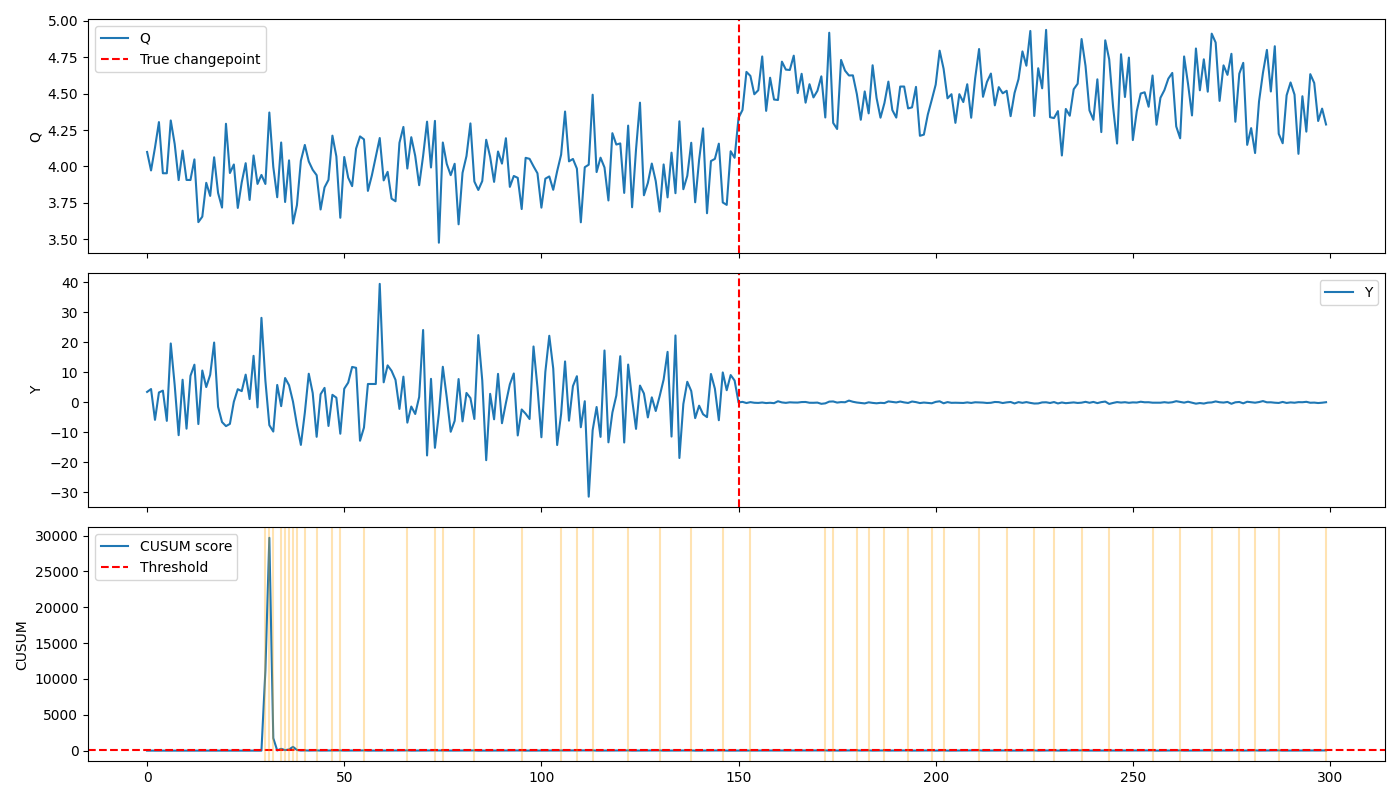

True changepoint: 150
First alarm: 30


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from BOCPD import build_features_local
from CUSUM import multivariate_cusum

np.random.seed(42)
n_normal = 150
n_leak = 150
Q1 = np.random.normal(4, 0.2, n_normal)
Y1 = np.random.normal(1, 10, n_normal)
Q2 = np.random.normal(4.5, 0.2, n_leak)
Y2 = np.random.normal(0, 0.2, n_leak)
Q = np.concatenate([Q1, Q2])
Y = np.concatenate([Y1, Y2])
true_cp = n_normal

X = build_features_local(Q, Y, window=30, min_periods=30)
cusum_scores, alarm, t2 = multivariate_cusum(X, window=30, min_periods=30, threshold=25.0, drift=1.0)

fig, ax = plt.subplots(3, 1, figsize=(14, 8), sharex=True)
ax[0].plot(Q, label='Q')
ax[0].axvline(true_cp, color='red', ls='--', label='True changepoint')
ax[0].set_ylabel('Q')
ax[0].legend()
ax[1].plot(Y, label='Y')
ax[1].axvline(true_cp, color='red', ls='--')
ax[1].set_ylabel('Y')
ax[1].legend()
ax[2].plot(cusum_scores, label='CUSUM score')
ax[2].axhline(25.0, color='red', ls='--', label='Threshold')
alarm_idx = np.where(alarm)[0]
for idx in alarm_idx:
    ax[2].axvline(idx, color='orange', alpha=0.3)
ax[2].set_ylabel('CUSUM')
ax[2].legend()
plt.tight_layout()
plt.show()
print(f'True changepoint: {true_cp}')
print(f'First alarm: {alarm_idx[0] if len(alarm_idx) else None}')
